## Exploration of the Data

In [ ]:
import pandas as pd

df = pd.read_csv("/workspaces/final-project-abshire/data/pitch_2024_relevant.csv")

# Basic checks
print(df.shape)       # rows, columns
print(df.columns)     # column names
df.head()             # first 5 rows
df.info()             # datatypes & null counts
df.describe()         # summary stats for numeric columns

# Check for duplicate rows
print(f"Duplicate rows: {df.duplicated().sum()}")
# 0 duplicate rows, that's huge

# Percentage of missing values per column
missing_percent = df.isnull().mean().sort_values(ascending=False) * 100
print(missing_percent)

# Unique counts for all object columns
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].nunique()} unique values")

### "events" = is the scorekeeper description
Nothing happened = NaN, out in the field, single, walk, double, home_run, triple

### "description" = granular, like ball, foul, swinging strike, hit into play

In [ ]:
# Target variable could be a few things... 
# Let's start with looking at description and events

print("Description value counts:")
print(df['description'].value_counts(dropna=False))

print("\nEvents value counts:")
print(df['events'].value_counts(dropna=False))

### Let's look at the unique pitch types

In [ ]:
df['pitch_type'].value_counts(dropna=False)

### Some of these are very rare...

- **SC** – Screwball  
- **EP** – Eephus  
- **FO** – Forkball  
- **FA** – Fastball  
- **FF** – Four-seam Fastball  
- **FT** – Two-seam Fastball  
- **FC** – Cutter (Fastball) 

### Let's look at hitting results first

In [17]:
# Unique events
print(df['events'].dropna().unique())

# Make a df with only hits!
hitting_events = ['single', 'double', 'triple', 'home_run']
df_hits = df[df['events'].isin(hitting_events)].copy()
print(f"Filtered to {len(df_hits)} rows with hit events")

# Check if there are any 0's in the luanch speed/angle
df_hits[['launch_speed', 'launch_angle']].isnull().mean() * 100


['strikeout' 'single' 'field_out' 'grounded_into_double_play' 'force_out'
 'double' 'field_error' 'walk' 'hit_by_pitch' 'fielders_choice' 'home_run'
 'double_play' 'fielders_choice_out' 'sac_fly' 'sac_bunt' 'triple'
 'catcher_interf' 'truncated_pa' 'sac_fly_double_play'
 'strikeout_double_play' 'triple_play']
Filtered to 39823 rows with hit events


launch_speed    0.163222
launch_angle    0.118022
dtype: float64

         launch_speed                                                      \
                count        mean        std   min    25%    50%      75%   
events                                                                      
double         7771.0   97.817179  10.243017  40.4   93.7  100.2  104.700   
home_run       5450.0  104.308055   4.314283  86.5  101.5  104.4  107.200   
single        25841.0   89.705615  15.461383   8.8   80.3   93.6  101.300   
triple          696.0   98.602443   7.398939  64.4   94.8  100.2  103.625   

                launch_angle                                                 \
            max        count       mean        std   min   25%   50%    75%   
events                                                                        
double    121.5       7771.0  16.563634  10.656925 -44.0  12.0  17.0  22.00   
home_run  119.9       5450.0  28.720000   5.154624  14.0  25.0  28.0  32.00   
single    120.4      25859.0   5.878108  18.550800 -88.0   0.0   

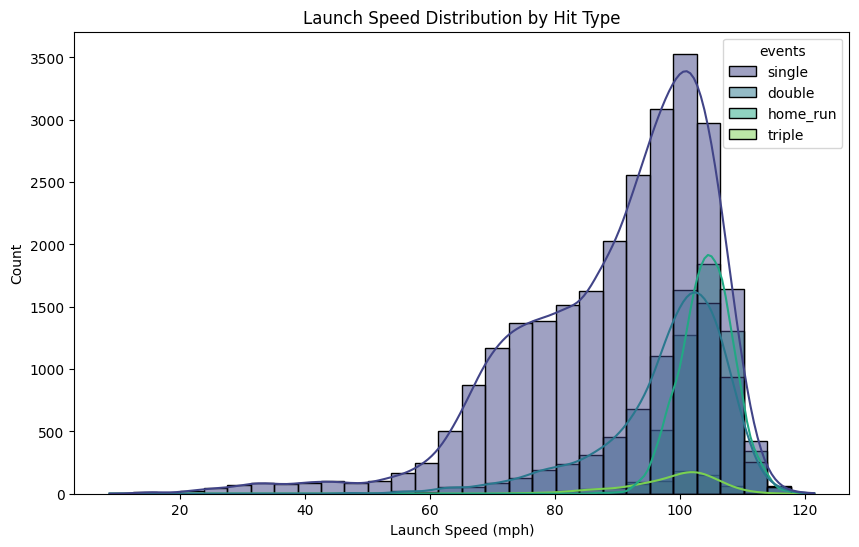

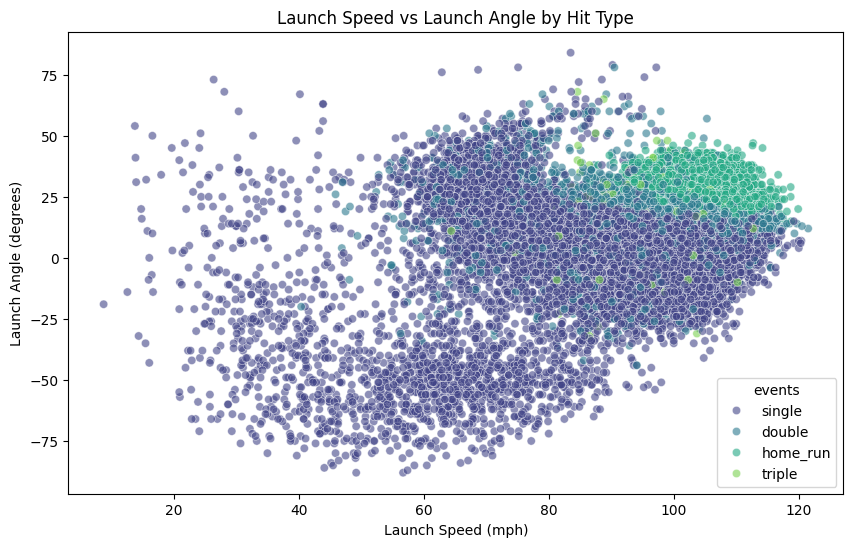

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Summary stats of launch speed and launch angle by hit type
summary_stats = df_hits.groupby('events')[['launch_speed', 'launch_angle']].describe()
print(summary_stats)

# Plot distribution of launch speed by hit type
plt.figure(figsize=(10, 6))
sns.histplot(data=df_hits, x='launch_speed', hue='events', bins=30, kde=True, palette='viridis')
plt.title('Launch Speed Distribution by Hit Type')
plt.xlabel('Launch Speed (mph)')
plt.ylabel('Count')
plt.show()

# Scatterplot of launch speed vs launch angle by hit type
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_hits, x='launch_speed', y='launch_angle', hue='events', alpha=0.6, palette='viridis')
plt.title('Launch Speed vs Launch Angle by Hit Type')
plt.xlabel('Launch Speed (mph)')
plt.ylabel('Launch Angle (degrees)')
plt.show()


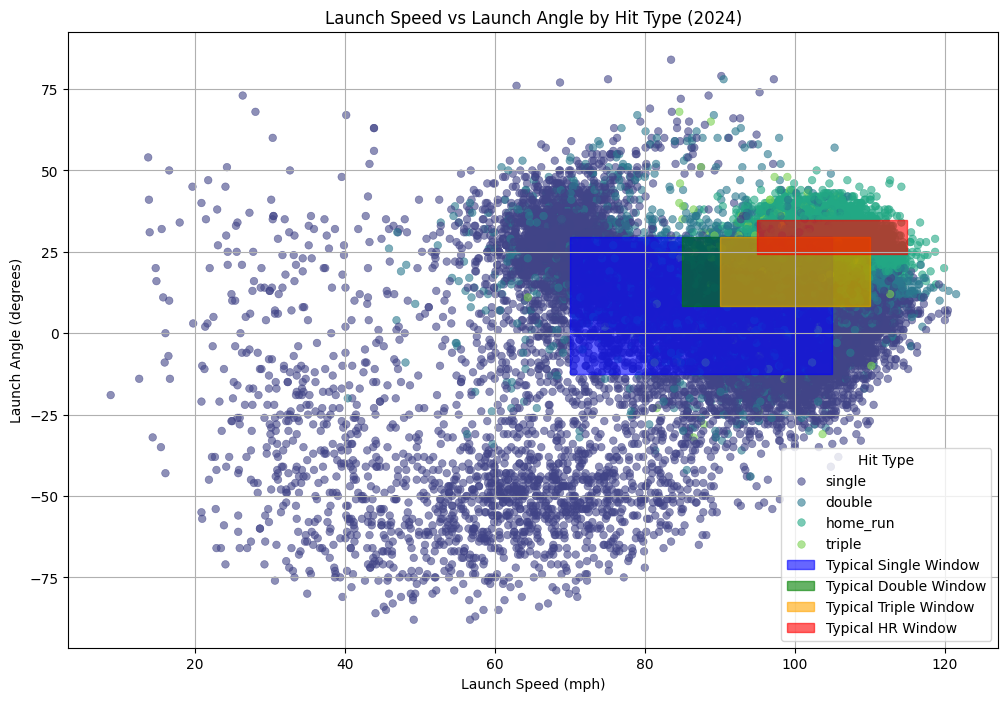

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

# Scatterplot of launch speed vs launch angle by hit type
sns.scatterplot(
    data=df_hits, 
    x='launch_speed', 
    y='launch_angle', 
    hue='events', 
    alpha=0.6, 
    palette='viridis',
    edgecolor=None,
    s=30
)

# Add shaded boxes for typical launch windows (approximate)

# Singles
plt.axvspan(70, 105, ymin=( -10 + 90)/180, ymax=(30 + 90)/180, color='blue', alpha=0.6, label='Typical Single Window')

# Doubles
plt.axvspan(85, 110, ymin=(10 + 90)/180, ymax=(30 + 90)/180, color='green', alpha=0.6, label='Typical Double Window')

# Triples
plt.axvspan(90, 110, ymin=(10 + 90)/180, ymax=(30 + 90)/180, color='orange', alpha=0.6, label='Typical Triple Window')

# Home Runs
plt.axvspan(95, 115, ymin=(25 + 90)/180, ymax=(35 + 90)/180, color='red', alpha=0.6, label='Typical HR Window')

plt.title('Launch Speed vs Launch Angle by Hit Type (2024)')
plt.xlabel('Launch Speed (mph)')
plt.ylabel('Launch Angle (degrees)')
plt.legend(title='Hit Type')
plt.grid(True)
plt.show()
